# Heart Disease Prediction - Group Work Notebook

- Data preprocessing
- Feature exploration
- Traditional machine learning models
- Evaluation
- Visualization


In [1]:
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'Heart_disease_cleveland_new.csv'
OUTPUT_DIR = BASE_DIR / 'group_outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('e:/DS Bachelor Degree Road/LMU Datascience/AI & ML (26.04)/Group AIML Code/Heart_disease_cleveland_new.csv')

## 1. Load the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [3]:
print('Dataset shape:', df.shape)
display(df.info())
display(df.describe())

Dataset shape: (303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


## 2. Data Preprocessing

In [4]:
print('Missing values by column:')
display(df.isnull().sum())

print('Duplicate rows before removal:', df.duplicated().sum())
df = df.drop_duplicates().copy()
print('Dataset shape after duplicate removal:', df.shape)

Missing values by column:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows before removal: 0
Dataset shape after duplicate removal: (303, 14)


In [5]:
df = df.replace('?', np.nan)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['target'] = (df['target'] > 0).astype(int)

print('Missing values after cleaning:')
display(df.isnull().sum())
display(df.head())

Missing values after cleaning:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [6]:
data_summary = pd.DataFrame([
    ['Rows', df.shape[0]],
    ['Columns', df.shape[1]],
    ['Class 0 count', int((df['target'] == 0).sum())],
    ['Class 1 count', int((df['target'] == 1).sum())],
], columns=['Metric', 'Value'])

data_summary.to_csv(TABLE_DIR / 'data_summary.csv', index=False)
df.describe().transpose().to_csv(TABLE_DIR / 'descriptive_statistics.csv')
data_summary

,Metric,Value
0,Rows,303
1,Columns,14
2,Class 0 count,164
3,Class 1 count,139


## 3. Feature Exploration

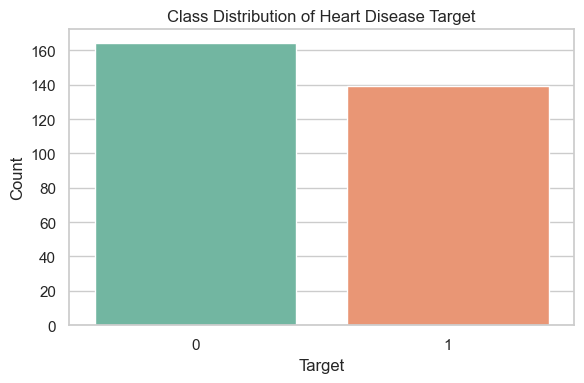

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Class Distribution of Heart Disease Target')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=300)
plt.show()

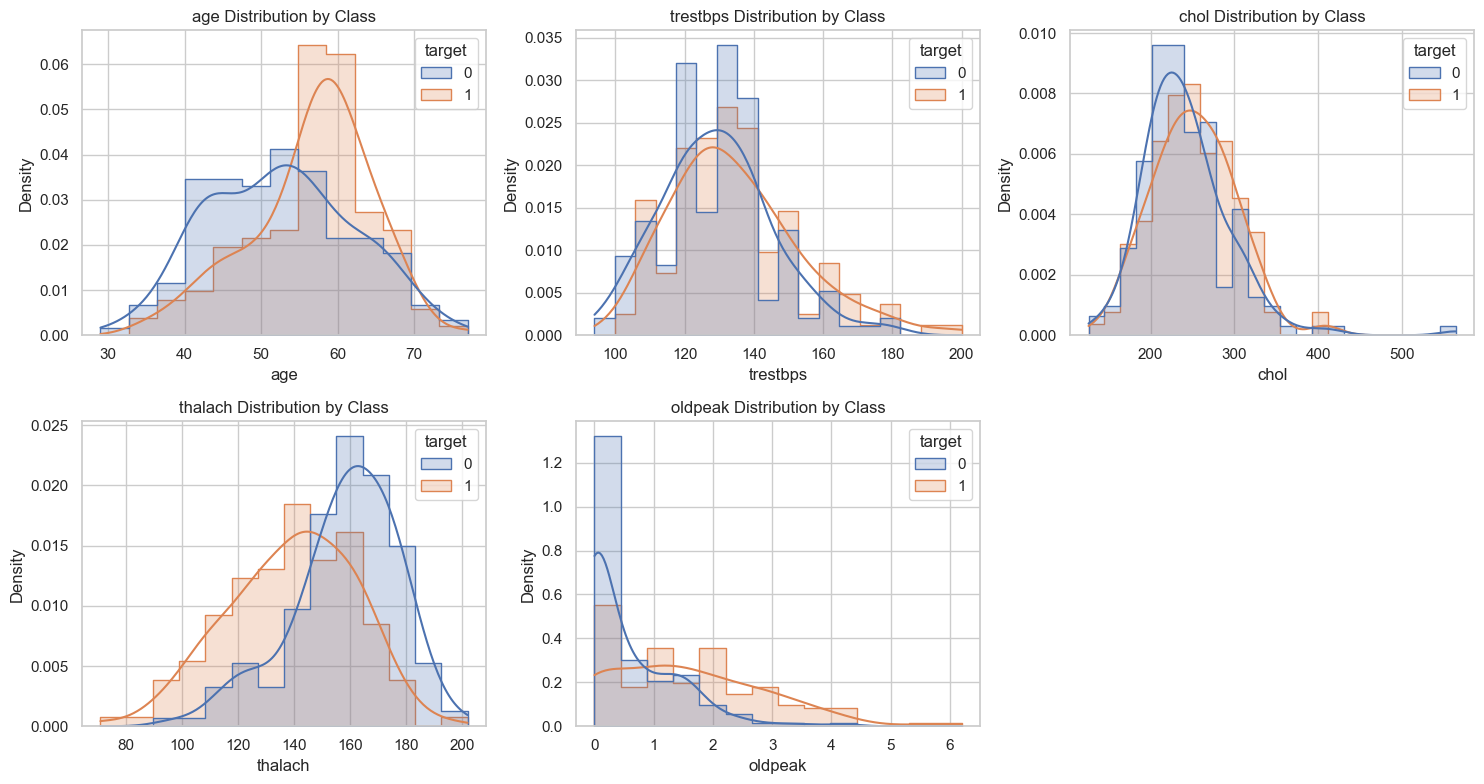

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for ax, feature in zip(axes.flatten(), hist_features):
    sns.histplot(data=df, x=feature, hue='target', kde=True, element='step', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{feature} Distribution by Class')

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'numeric_feature_distributions.png', dpi=300)
plt.show()

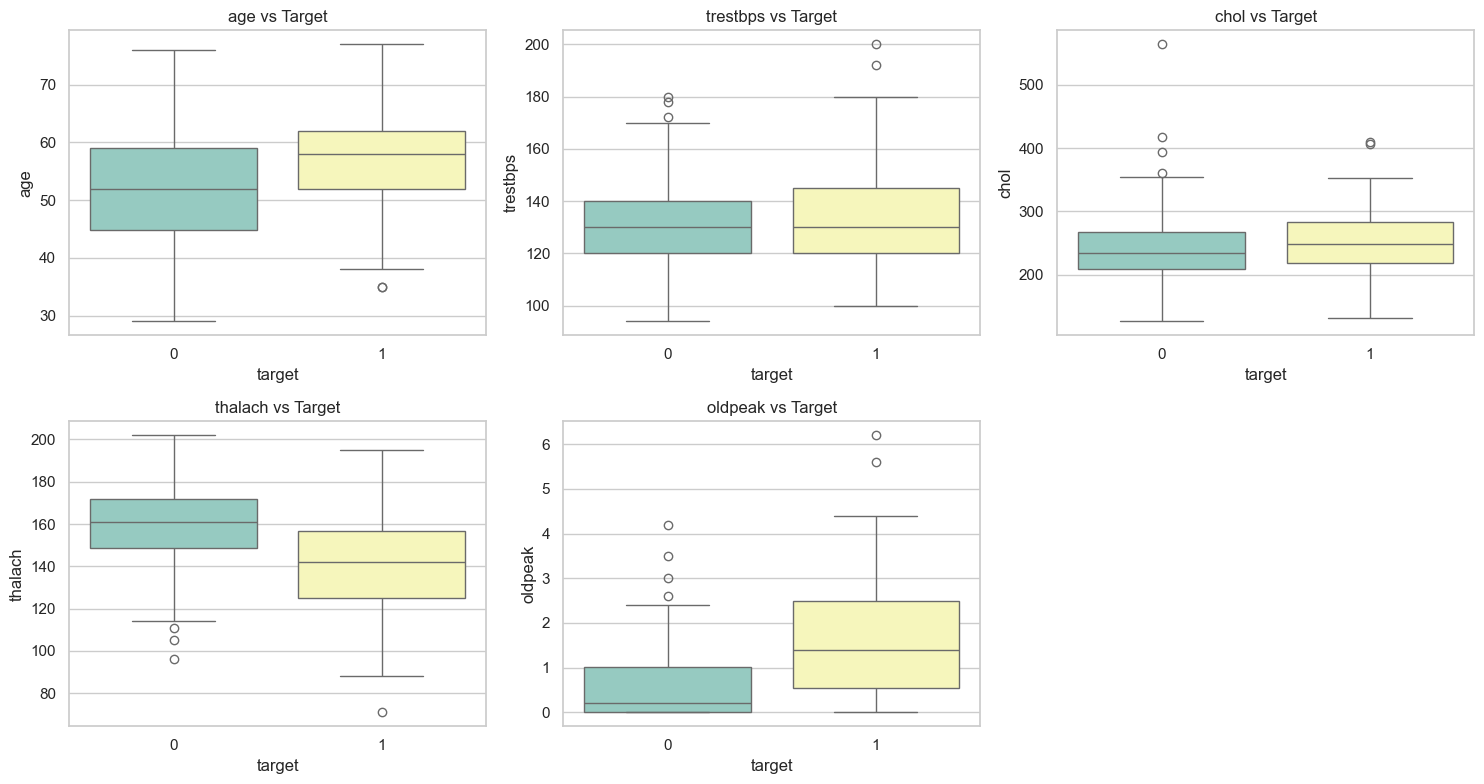

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
box_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for ax, feature in zip(axes.flatten(), box_features):
    sns.boxplot(data=df, x='target', y=feature, palette='Set3', ax=ax)
    ax.set_title(f'{feature} vs Target')

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplots_by_class.png', dpi=300)
plt.show()

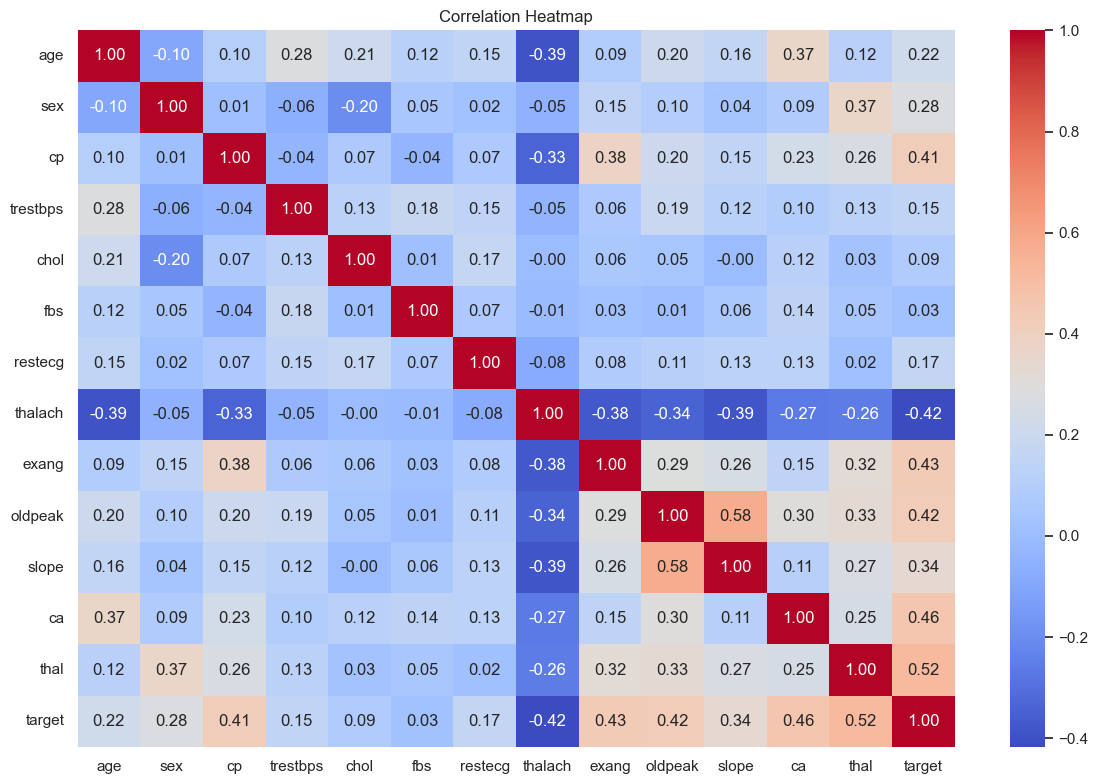

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=300)
plt.show()

## 4. Prepare Features for Machine Learning

In [11]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Scaled train shape:', X_train_scaled.shape)

X_train.to_csv(TABLE_DIR / 'X_train_unscaled.csv', index=False)
X_test.to_csv(TABLE_DIR / 'X_test_unscaled.csv', index=False)
X_train_scaled.to_csv(TABLE_DIR / 'X_train_scaled.csv', index=False)
X_test_scaled.to_csv(TABLE_DIR / 'X_test_scaled.csv', index=False)
y_train.to_csv(TABLE_DIR / 'y_train.csv', index=False)
y_test.to_csv(TABLE_DIR / 'y_test.csv', index=False)

Train shape: (242, 20)
Test shape: (61, 20)
Scaled train shape: (242, 20)


## 5. Train Traditional Machine Learning Models

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=42),
        'param_grid': {
            'C': [0.1, 1.0, 3.0],
            'solver': ['liblinear', 'lbfgs']
        },
        'train_X': X_train_scaled,
        'test_X': X_test_scaled,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [200, 400],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]
        },
        'train_X': X_train,
        'test_X': X_test,
    },
    'SVM': {
        'estimator': SVC(probability=True, random_state=42),
        'param_grid': {
            'C': [0.5, 1.0, 2.0],
            'gamma': ['scale', 0.1],
            'kernel': ['rbf']
        },
        'train_X': X_train_scaled,
        'test_X': X_test_scaled,
    }
}

best_models = {}
results_rows = []
cv_rows = []
prediction_store = {}


In [13]:
for model_name, config in model_configs.items():
    search = GridSearchCV(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    
    search.fit(config['train_X'], y_train)
    best_model = search.best_estimator_
    best_models[model_name] = best_model
    
    y_pred = best_model.predict(config['test_X'])
    y_score = best_model.predict_proba(config['test_X'])[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    
    prediction_store[model_name] = {
        'y_pred': y_pred,
        'y_score': y_score,
        'confusion_matrix': cm,
    }
    
    results_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score),
        'TN': int(cm[0, 0]),
        'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]),
        'TP': int(cm[1, 1]),
    })
    
    cv_rows.append({
        'Model': model_name,
        'Best ROC-AUC (CV)': search.best_score_,
        'Best Parameters': str(search.best_params_),
    })
    
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred,
        'y_score': y_score,
    }).to_csv(TABLE_DIR / f"{model_name.lower().replace(' ', '_')}_predictions.csv", index=False)
    
results_df = pd.DataFrame(results_rows).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
cv_df = pd.DataFrame(cv_rows)

results_df.to_csv(TABLE_DIR / 'group_model_metrics.csv', index=False)
cv_df.to_csv(TABLE_DIR / 'group_model_cv_summary.csv', index=False)

display(results_df)
display(cv_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.885246,0.862069,0.892857,0.877193,0.955628,29,4,3,25
1,Random Forest,0.868852,0.833333,0.892857,0.862069,0.948052,28,5,3,25
2,SVM,0.836066,0.750000,0.964286,0.843750,0.930736,24,9,1,27


,Model,Best ROC-AUC (CV),Best Parameters
0,Logistic Regression,0.903188,"{'C': 0.1, 'solver': 'liblinear'}"
1,Random Forest,0.887972,"{'max_depth': 5, 'min_samples_split': 5, 'n_es..."
2,SVM,0.893848,"{'C': 0.5, 'gamma': 0.1, 'kernel': 'rbf'}"


## 6. Confusion Matrices

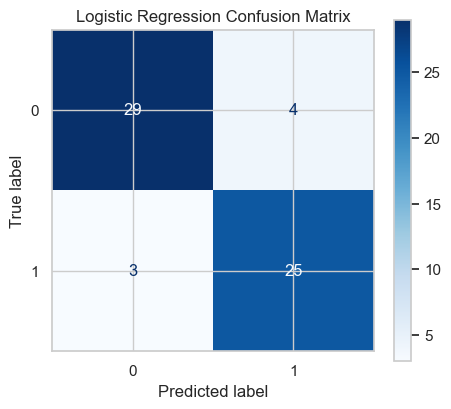

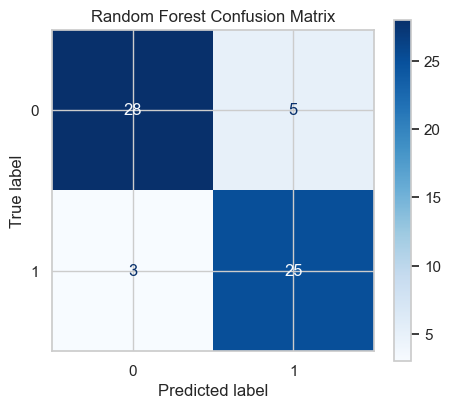

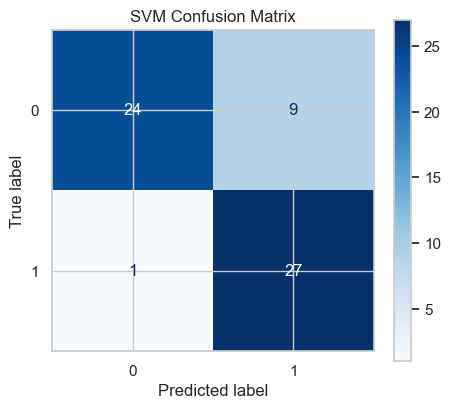

In [14]:
for model_name, output in prediction_store.items():
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ConfusionMatrixDisplay(confusion_matrix=output['confusion_matrix']).plot(cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=300)
    plt.show()

## 7. ROC Curve Comparison

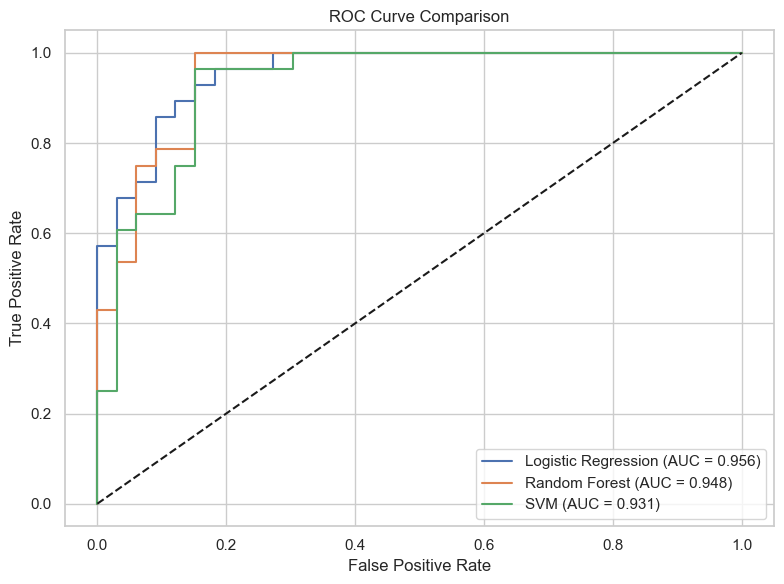

In [15]:
plt.figure(figsize=(8, 6))

for model_name, output in prediction_store.items():
    fpr, tpr, _ = roc_curve(y_test, output['y_score'])
    auc_score = roc_auc_score(y_test, output['y_score'])
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_curve_comparison.png', dpi=300)
plt.show()

## 8. Feature Importance

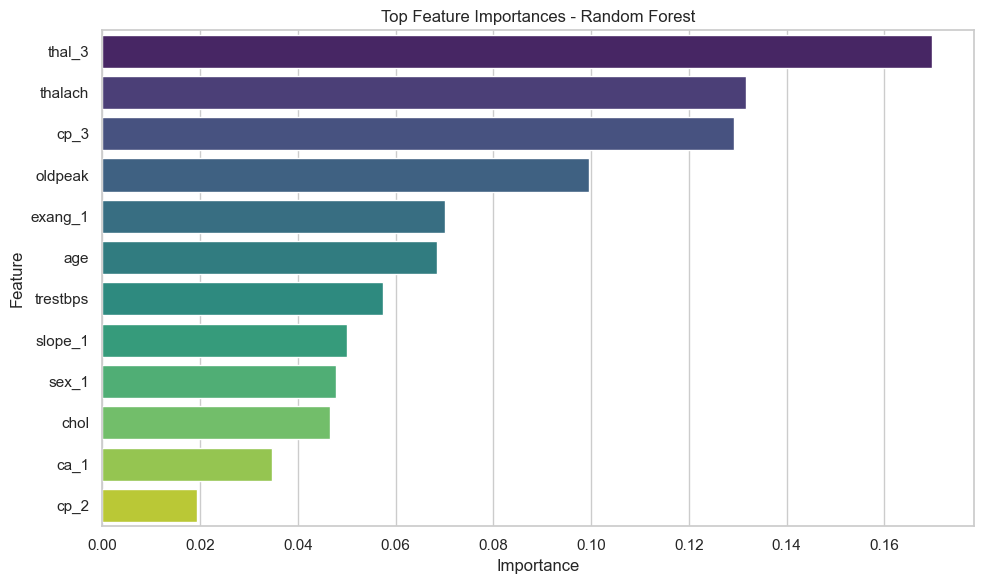

In [16]:
rf_model = best_models['Random Forest']
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, palette='viridis', legend=False)
plt.title('Top Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(FIG_DIR / 'random_forest_feature_importance.png', dpi=300)
plt.show()

feature_importance.to_csv(TABLE_DIR / 'random_forest_feature_importance.csv', header=['Importance'])

## 9. Model Performance Comparison Chart

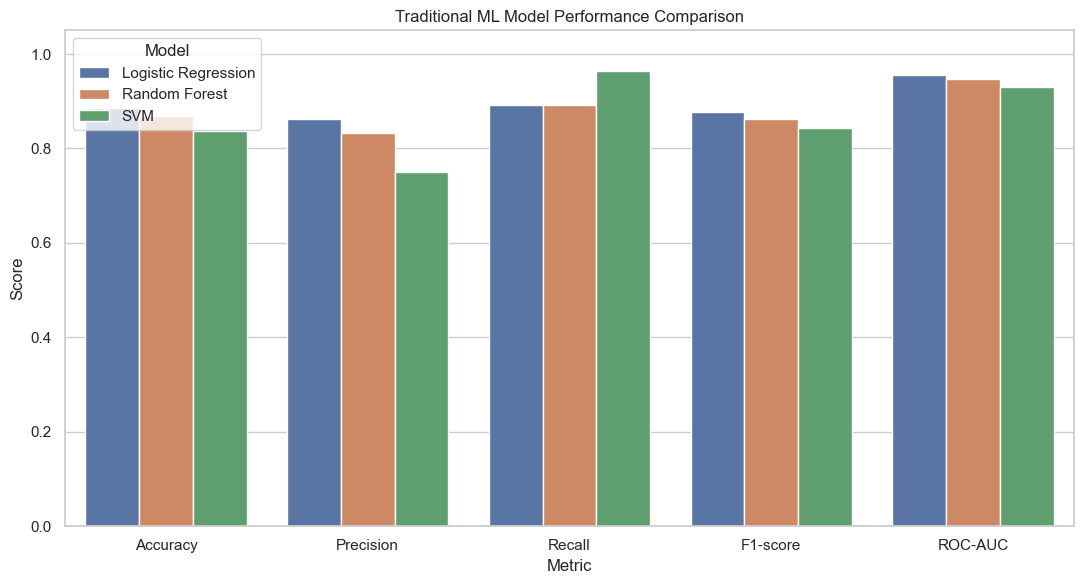

In [17]:
plot_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title('Traditional ML Model Performance Comparison')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_performance_comparison.png', dpi=300)
plt.show()

## 10. Final Interpretation Notes

In [18]:
best_model_row = results_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]

interpretation_notes = [
    f"Best overall model by ROC-AUC: {best_model_row['Model']} ({best_model_row['ROC-AUC']:.4f})",
    'Recall is especially important in this medical prediction task because false negatives mean missed disease cases.',
    'Logistic Regression and SVM benefit from scaling, while Random Forest also provides feature importance for interpretability.',
    'The final model choice should consider not only accuracy, but also recall, F1-score, ROC-AUC, and interpretability.',
]

for note in interpretation_notes:
    print('-', note)

with open(TABLE_DIR / 'interpretation_notes.txt', 'w', encoding='utf-8') as f:
    for note in interpretation_notes:
        f.write(note + '\n')

- Best overall model by ROC-AUC: Logistic Regression (0.9556)
- Recall is especially important in this medical prediction task because false negatives mean missed disease cases.
- Logistic Regression and SVM benefit from scaling, while Random Forest also provides feature importance for interpretability.
- The final model choice should consider not only accuracy, but also recall, F1-score, ROC-AUC, and interpretability.


## 11. Final Saved Outputs

This notebook saves report-ready tables and figures to:

- `group_outputs/tables/`
- `group_outputs/figures/`

These outputs can be directly used in the group report.

In [19]:
sorted([p.name for p in TABLE_DIR.iterdir()]), sorted([p.name for p in FIG_DIR.iterdir()])

(['X_test_scaled.csv',
  'X_test_unscaled.csv',
  'X_train_scaled.csv',
  'X_train_unscaled.csv',
  'data_summary.csv',
  'descriptive_statistics.csv',
  'group_model_cv_summary.csv',
  'group_model_metrics.csv',
  'interpretation_notes.txt',
  'logistic_regression_predictions.csv',
  'random_forest_feature_importance.csv',
  'random_forest_predictions.csv',
  'svm_predictions.csv',
  'y_test.csv',
  'y_train.csv'],
 ['boxplots_by_class.png',
  'class_distribution.png',
  'correlation_heatmap.png',
  'logistic_regression_confusion_matrix.png',
  'model_performance_comparison.png',
  'numeric_feature_distributions.png',
  'random_forest_confusion_matrix.png',
  'random_forest_feature_importance.png',
  'roc_curve_comparison.png',
  'svm_confusion_matrix.png'])